In [2]:
# Cell 1 — BIDMC signal-processing validation setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import wfdb

from scipy.signal import butter, sosfiltfilt, find_peaks


# ============================================================
# Project paths
# ============================================================

PROJECT_ROOT = Path("..").resolve()
REPORTS_DIR = PROJECT_ROOT / "reports"

# BIDMC PhysioNet dataset
BIDMC_PATH = "https://physionet.org/files/bidmc/1.0.0/"


# ============================================================
# Validation configuration
# ============================================================

VALIDATION_RECORD = "bidmc01"


# ============================================================
# Display setup
# ============================================================

print("=" * 70)
print("BIDMC SIGNAL-PROCESSING VALIDATION")
print("=" * 70)

print()
print("Project root:")
print(PROJECT_ROOT)

print()
print("Reports directory:")
print(REPORTS_DIR)

print()
print("BIDMC dataset:")
print(BIDMC_PATH)

print()
print("Validation record:")
print(VALIDATION_RECORD)

print()
print("=" * 70)
print("SETUP COMPLETE")
print("=" * 70)

BIDMC SIGNAL-PROCESSING VALIDATION

Project root:
C:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor

Reports directory:
C:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports

BIDMC dataset:
https://physionet.org/files/bidmc/1.0.0/

Validation record:
bidmc01

SETUP COMPLETE


In [3]:
# Cell 2 — Load and inspect BIDMC record

print("=" * 70)
print("LOADING BIDMC RECORD")
print("=" * 70)

# Load the BIDMC record directly from PhysioNet
bidmc_record = wfdb.rdrecord(
    VALIDATION_RECORD,
    pn_dir="bidmc/1.0.0"
)

print()
print("Record name:")
print(bidmc_record.record_name)

print()
print("Sampling frequency:")
print(bidmc_record.fs, "Hz")

print()
print("Number of samples:")
print(bidmc_record.sig_len)

print()
print("Duration:")
print(
    f"{bidmc_record.sig_len / bidmc_record.fs / 60:.2f} minutes"
)

print()
print("Number of channels:")
print(bidmc_record.n_sig)

print()
print("Channel names:")
print(bidmc_record.sig_name)

print()
print("Signal units:")
print(bidmc_record.units)

print()
print("=" * 70)
print("BIDMC RECORD LOADED")
print("=" * 70)

LOADING BIDMC RECORD

Record name:
bidmc01

Sampling frequency:
125 Hz

Number of samples:
60001

Duration:
8.00 minutes

Number of channels:
5

Channel names:
['RESP,', 'PLETH,', 'V,', 'AVR,', 'II,']

Signal units:
['pm', 'NU', 'mV', 'mV', 'mV']

BIDMC RECORD LOADED


In [4]:
# Cell 3 — Inspect exact BIDMC channel names

print("=" * 70)
print("INSPECTING EXACT CHANNEL NAMES")
print("=" * 70)

print()

for i, name in enumerate(bidmc_record.sig_name):
    print(
        f"Channel {i}: {repr(name)}"
    )

print()
print("Channel-name character codes:")

for i, name in enumerate(bidmc_record.sig_name):
    print(
        f"Channel {i}:",
        [ord(char) for char in name]
    )

print()
print("=" * 70)
print("CHANNEL NAME INSPECTION COMPLETE")
print("=" * 70)

INSPECTING EXACT CHANNEL NAMES

Channel 0: 'RESP,'
Channel 1: 'PLETH,'
Channel 2: 'V,'
Channel 3: 'AVR,'
Channel 4: 'II,'

Channel-name character codes:
Channel 0: [82, 69, 83, 80, 44]
Channel 1: [80, 76, 69, 84, 72, 44]
Channel 2: [86, 44]
Channel 3: [65, 86, 82, 44]
Channel 4: [73, 73, 44]

CHANNEL NAME INSPECTION COMPLETE


In [5]:
# Cell 4 — Extract BIDMC physiological signals

print("=" * 70)
print("EXTRACTING BIDMC SIGNALS")
print("=" * 70)

# BIDMC channel indices confirmed from Cell 3
RESP_CHANNEL = 0
PPG_CHANNEL = 1
ECG_CHANNEL = 4

# Extract signals directly by channel index
resp_signal = bidmc_record.p_signal[:, RESP_CHANNEL]
ppg_signal = bidmc_record.p_signal[:, PPG_CHANNEL]
ecg_signal = bidmc_record.p_signal[:, ECG_CHANNEL]

# Sampling frequency
BIDMC_FS = float(bidmc_record.fs)

print()
print("Selected channels:")
print("RESP :", bidmc_record.sig_name[RESP_CHANNEL])
print("PPG  :", bidmc_record.sig_name[PPG_CHANNEL])
print("ECG  :", bidmc_record.sig_name[ECG_CHANNEL])

print()
print("Signal shapes:")
print("RESP :", resp_signal.shape)
print("PPG  :", ppg_signal.shape)
print("ECG  :", ecg_signal.shape)

print()
print("Sampling frequency:")
print(BIDMC_FS, "Hz")

print()
print("NaN counts:")
print("RESP :", np.isnan(resp_signal).sum())
print("PPG  :", np.isnan(ppg_signal).sum())
print("ECG  :", np.isnan(ecg_signal).sum())

print()
print("Signal ranges:")
print(
    f"RESP : {np.min(resp_signal):.6f} to "
    f"{np.max(resp_signal):.6f}"
)
print(
    f"PPG  : {np.min(ppg_signal):.6f} to "
    f"{np.max(ppg_signal):.6f}"
)
print(
    f"ECG  : {np.min(ecg_signal):.6f} to "
    f"{np.max(ecg_signal):.6f}"
)

print()
print("=" * 70)
print("SIGNAL EXTRACTION COMPLETE")
print("=" * 70)

EXTRACTING BIDMC SIGNALS

Selected channels:
RESP : RESP,
PPG  : PLETH,
ECG  : II,

Signal shapes:
RESP : (60001,)
PPG  : (60001,)
ECG  : (60001,)

Sampling frequency:
125.0 Hz

NaN counts:
RESP : 0
PPG  : 0
ECG  : 0

Signal ranges:
RESP : 0.000000 to 1.000000
PPG  : 0.223852 to 0.697948
ECG  : -0.501976 to 1.503907

SIGNAL EXTRACTION COMPLETE


RAW BIDMC SIGNAL VISUALIZATION


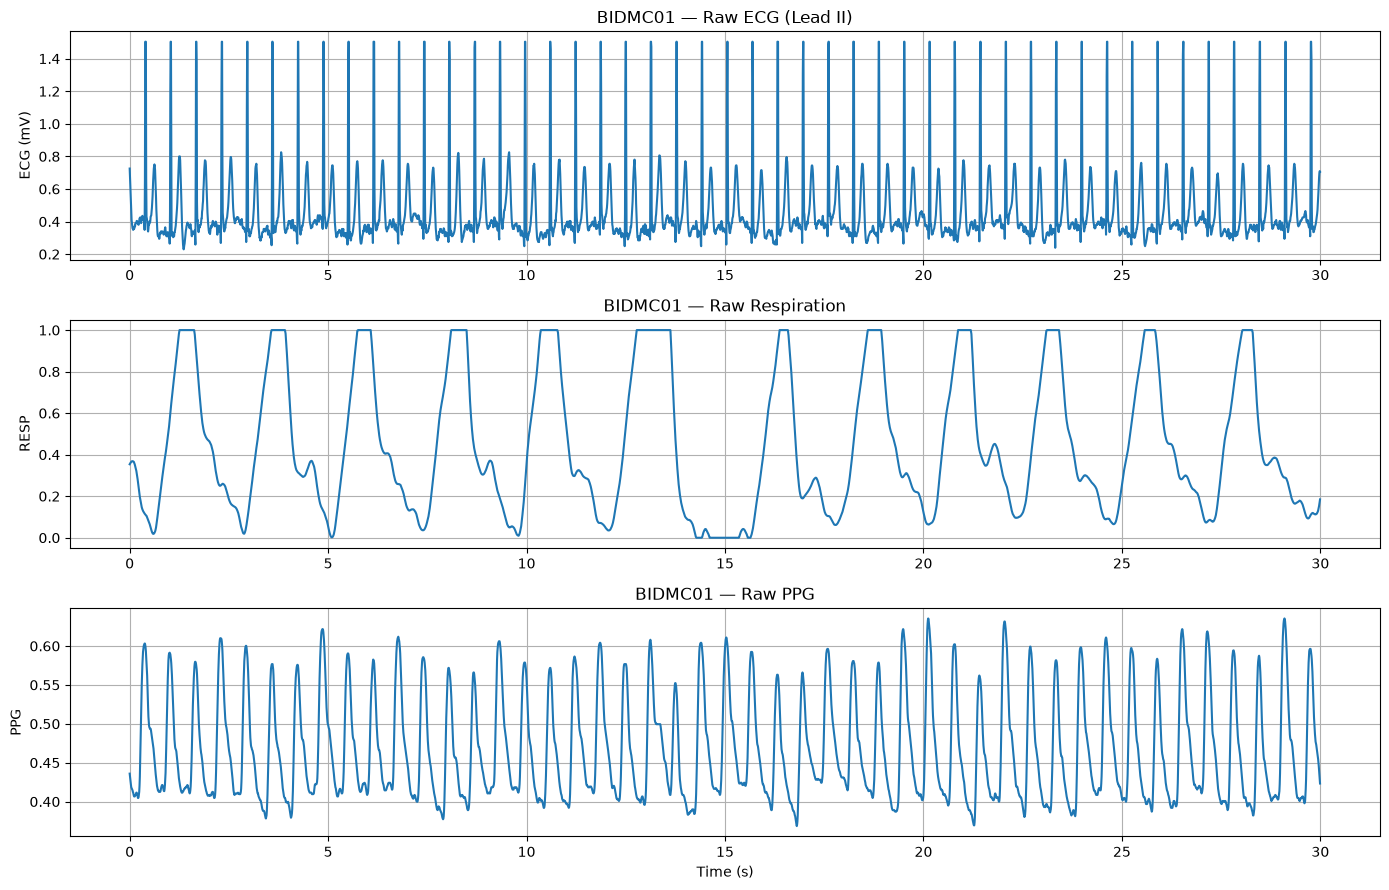


Displayed duration: 30.0 seconds
RAW SIGNAL VISUALIZATION COMPLETE


In [6]:
# Cell 5 — Visualize raw BIDMC signals

print("=" * 70)
print("RAW BIDMC SIGNAL VISUALIZATION")
print("=" * 70)

# Display the first 30 seconds
PLOT_DURATION = 30.0
plot_samples = int(PLOT_DURATION * BIDMC_FS)

time_axis = np.arange(plot_samples) / BIDMC_FS

plt.figure(figsize=(14, 9))

plt.subplot(3, 1, 1)
plt.plot(time_axis, ecg_signal[:plot_samples])
plt.ylabel("ECG (mV)")
plt.title("BIDMC01 — Raw ECG (Lead II)")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(time_axis, resp_signal[:plot_samples])
plt.ylabel("RESP")
plt.title("BIDMC01 — Raw Respiration")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(time_axis, ppg_signal[:plot_samples])
plt.xlabel("Time (s)")
plt.ylabel("PPG")
plt.title("BIDMC01 — Raw PPG")
plt.grid(True)

plt.tight_layout()
plt.show()

print()
print("Displayed duration:", PLOT_DURATION, "seconds")
print("=" * 70)
print("RAW SIGNAL VISUALIZATION COMPLETE")
print("=" * 70)

In [7]:
# Cell 6 — BIDMC ECG bandpass filtering

print("=" * 70)
print("BIDMC ECG BANDPASS FILTERING")
print("=" * 70)

# ECG bandpass configuration
ECG_LOW_CUTOFF = 0.5
ECG_HIGH_CUTOFF = 40.0
ECG_FILTER_ORDER = 4

# Design Butterworth bandpass filter using SOS
ecg_sos = butter(
    ECG_FILTER_ORDER,
    [ECG_LOW_CUTOFF, ECG_HIGH_CUTOFF],
    btype="bandpass",
    fs=BIDMC_FS,
    output="sos"
)

# Apply zero-phase filtering
ecg_filtered = sosfiltfilt(
    ecg_sos,
    ecg_signal
)

print()
print("Filter type:")
print("Butterworth bandpass")

print()
print("Low cutoff:")
print(ECG_LOW_CUTOFF, "Hz")

print()
print("High cutoff:")
print(ECG_HIGH_CUTOFF, "Hz")

print()
print("Filter order:")
print(ECG_FILTER_ORDER)

print()
print("Original ECG range:")
print(
    f"{np.min(ecg_signal):.6f} to "
    f"{np.max(ecg_signal):.6f} mV"
)

print()
print("Filtered ECG range:")
print(
    f"{np.min(ecg_filtered):.6f} to "
    f"{np.max(ecg_filtered):.6f} mV"
)

print()
print("NaN count after filtering:")
print(np.isnan(ecg_filtered).sum())

print()
print("=" * 70)
print("ECG BANDPASS FILTERING COMPLETE")
print("=" * 70)

BIDMC ECG BANDPASS FILTERING

Filter type:
Butterworth bandpass

Low cutoff:
0.5 Hz

High cutoff:
40.0 Hz

Filter order:
4

Original ECG range:
-0.501976 to 1.503907 mV

Filtered ECG range:
-1.086439 to 1.244298 mV

NaN count after filtering:
0

ECG BANDPASS FILTERING COMPLETE


BIDMC ECG FILTER VALIDATION


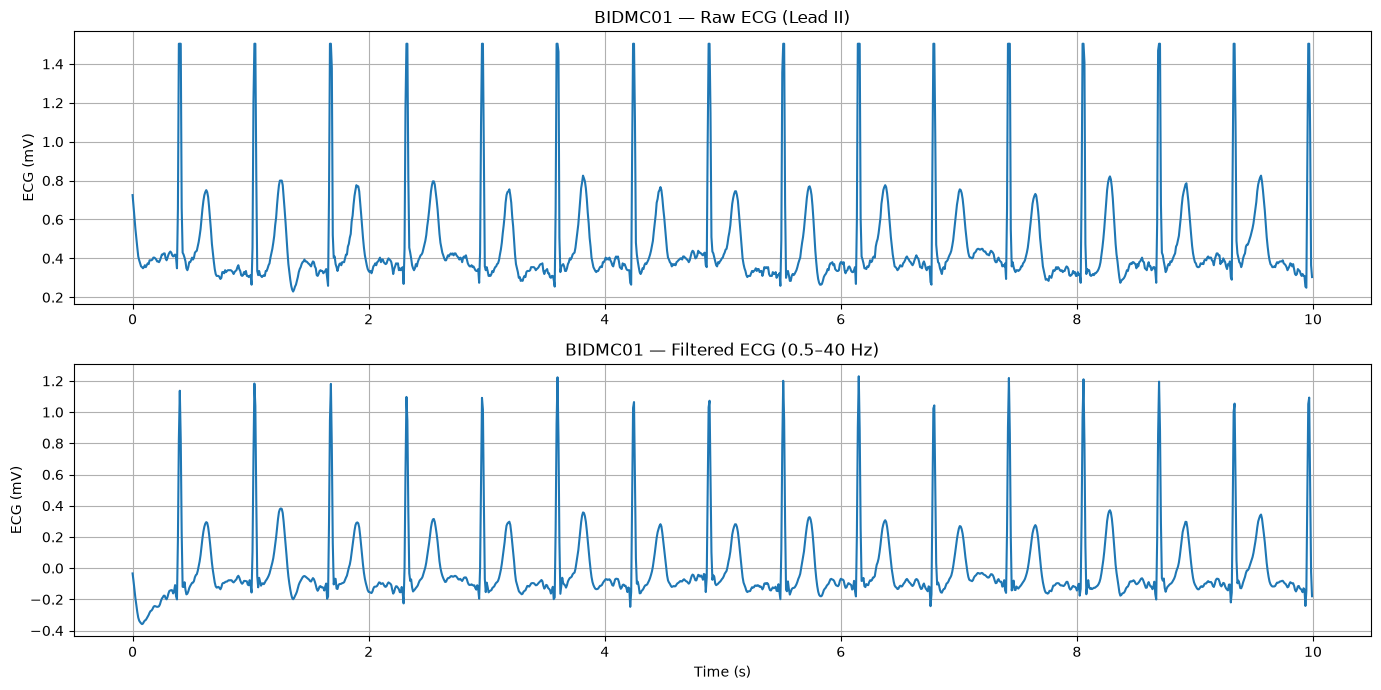


Displayed duration: 10.0 seconds

ECG FILTER VISUALIZATION COMPLETE


In [8]:
# Cell 7 — Visualize raw vs filtered BIDMC ECG

print("=" * 70)
print("BIDMC ECG FILTER VALIDATION")
print("=" * 70)

# First 10 seconds
PLOT_DURATION_ECG = 10.0
plot_samples_ecg = int(PLOT_DURATION_ECG * BIDMC_FS)

time_ecg = np.arange(plot_samples_ecg) / BIDMC_FS

plt.figure(figsize=(14, 7))

plt.subplot(2, 1, 1)
plt.plot(time_ecg, ecg_signal[:plot_samples_ecg])
plt.ylabel("ECG (mV)")
plt.title("BIDMC01 — Raw ECG (Lead II)")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(time_ecg, ecg_filtered[:plot_samples_ecg])
plt.xlabel("Time (s)")
plt.ylabel("ECG (mV)")
plt.title("BIDMC01 — Filtered ECG (0.5–40 Hz)")
plt.grid(True)

plt.tight_layout()
plt.show()

print()
print("Displayed duration:", PLOT_DURATION_ECG, "seconds")
print()
print("=" * 70)
print("ECG FILTER VISUALIZATION COMPLETE")
print("=" * 70)

In [9]:
# Cell 8 — BIDMC ECG R-peak detection

print("=" * 70)
print("BIDMC ECG R-PEAK DETECTION")
print("=" * 70)

# Detect R-peaks from filtered ECG
ecg_peaks, ecg_peak_properties = find_peaks(
    ecg_filtered,
    distance=int(0.30 * BIDMC_FS),
    prominence=0.3
)

# Convert sample indices to seconds
ecg_peak_times = ecg_peaks / BIDMC_FS

print()
print("Detected R-peaks:")
print(len(ecg_peaks))

print()
print("Minimum peak distance:")
print(f"{0.30:.2f} seconds")

print()
print("Peak prominence:")
print("0.3 mV")

print()
print("First 10 R-peak times (s):")
print(ecg_peak_times[:10])

print()
print("Last 10 R-peak times (s):")
print(ecg_peak_times[-10:])

print()
print("=" * 70)
print("R-PEAK DETECTION COMPLETE")
print("=" * 70)

BIDMC ECG R-PEAK DETECTION

Detected R-peaks:
730

Minimum peak distance:
0.30 seconds

Peak prominence:
0.3 mV

First 10 R-peak times (s):
[0.4   1.032 1.68  2.32  2.96  3.6   4.248 4.888 5.512 6.152]

Last 10 R-peak times (s):
[473.512 474.176 474.84  475.504 476.184 476.848 477.512 478.176 478.848
 479.52 ]

R-PEAK DETECTION COMPLETE


BIDMC R-PEAK VISUAL VALIDATION


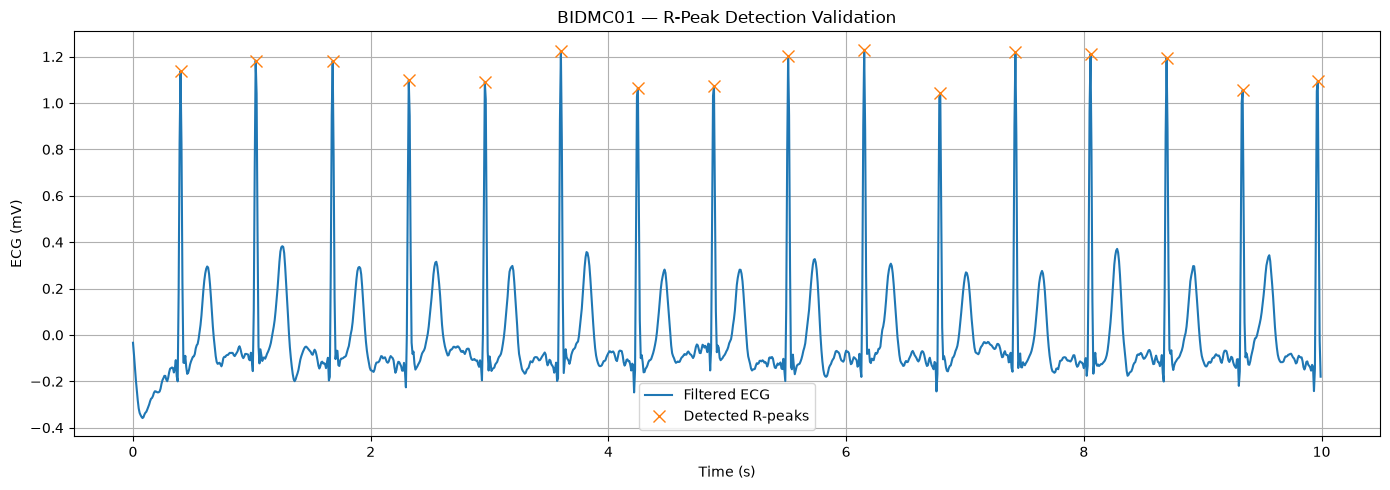


Displayed duration: 10.0 seconds

R-PEAK VISUAL VALIDATION COMPLETE


In [10]:
# Cell 9 — Visual validation of BIDMC R-peaks

print("=" * 70)
print("BIDMC R-PEAK VISUAL VALIDATION")
print("=" * 70)

# Display the first 10 seconds
PLOT_DURATION_PEAKS = 10.0
plot_samples_peaks = int(PLOT_DURATION_PEAKS * BIDMC_FS)

time_peaks = np.arange(plot_samples_peaks) / BIDMC_FS

plt.figure(figsize=(14, 5))

plt.plot(
    time_peaks,
    ecg_filtered[:plot_samples_peaks],
    label="Filtered ECG"
)

# Select detected peaks inside the displayed interval
peak_mask = ecg_peak_times <= PLOT_DURATION_PEAKS

plt.plot(
    ecg_peak_times[peak_mask],
    ecg_filtered[ecg_peaks[peak_mask]],
    "x",
    markersize=8,
    label="Detected R-peaks"
)

plt.xlabel("Time (s)")
plt.ylabel("ECG (mV)")
plt.title("BIDMC01 — R-Peak Detection Validation")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print()
print("Displayed duration:", PLOT_DURATION_PEAKS, "seconds")
print()
print("=" * 70)
print("R-PEAK VISUAL VALIDATION COMPLETE")
print("=" * 70)

In [11]:
# Cell 10 — BIDMC RR intervals and heart rate

print("=" * 70)
print("BIDMC RR INTERVAL AND HEART-RATE ANALYSIS")
print("=" * 70)

# Calculate RR intervals
rr_intervals = np.diff(ecg_peak_times)

# Heart rate from RR intervals
heart_rate = 60.0 / rr_intervals

# Time associated with each RR interval
hr_times = ecg_peak_times[1:]

print()
print("Number of RR intervals:")
print(len(rr_intervals))

print()
print("RR interval statistics:")
print(f"Mean : {np.mean(rr_intervals):.4f} s")
print(f"Min  : {np.min(rr_intervals):.4f} s")
print(f"Max  : {np.max(rr_intervals):.4f} s")
print(f"Std  : {np.std(rr_intervals):.4f} s")

print()
print("Heart-rate statistics:")
print(f"Mean : {np.mean(heart_rate):.2f} BPM")
print(f"Min  : {np.min(heart_rate):.2f} BPM")
print(f"Max  : {np.max(heart_rate):.2f} BPM")
print(f"Std  : {np.std(heart_rate):.2f} BPM")

print()
print("NaN counts:")
print("RR intervals :", np.isnan(rr_intervals).sum())
print("Heart rate   :", np.isnan(heart_rate).sum())

print()
print("=" * 70)
print("RR AND HEART-RATE ANALYSIS COMPLETE")
print("=" * 70)

BIDMC RR INTERVAL AND HEART-RATE ANALYSIS

Number of RR intervals:
729

RR interval statistics:
Mean : 0.6572 s
Min  : 0.4640 s
Max  : 0.8880 s
Std  : 0.0216 s

Heart-rate statistics:
Mean : 91.40 BPM
Min  : 67.57 BPM
Max  : 129.31 BPM
Std  : 3.27 BPM

NaN counts:
RR intervals : 0
Heart rate   : 0

RR AND HEART-RATE ANALYSIS COMPLETE


In [12]:
# Cell 11 — BIDMC HRV analysis

print("=" * 70)
print("BIDMC HRV ANALYSIS")
print("=" * 70)

# SDNN: standard deviation of NN/RR intervals
sdnn = np.std(rr_intervals, ddof=1)

# RMSSD: root mean square of successive RR differences
rr_differences = np.diff(rr_intervals)

rmssd = np.sqrt(
    np.mean(rr_differences ** 2)
)

print()
print("HRV metrics:")

print()
print(f"SDNN  : {sdnn * 1000:.2f} ms")

print()
print(f"RMSSD : {rmssd * 1000:.2f} ms")

print()
print("Supporting values:")
print(f"RR intervals          : {len(rr_intervals)}")
print(f"Successive differences: {len(rr_differences)}")

print()
print("NaN counts:")
print("SDNN :", np.isnan(sdnn))
print("RMSSD:", np.isnan(rmssd))

print()
print("=" * 70)
print("HRV ANALYSIS COMPLETE")
print("=" * 70)

BIDMC HRV ANALYSIS

HRV metrics:

SDNN  : 21.64 ms

RMSSD : 33.40 ms

Supporting values:
RR intervals          : 729
Successive differences: 728

NaN counts:
SDNN : False
RMSSD: False

HRV ANALYSIS COMPLETE


In [13]:
# Cell 12 — BIDMC respiration bandpass filtering

print("=" * 70)
print("BIDMC RESPIRATION BANDPASS FILTERING")
print("=" * 70)

# Respiration filter configuration
RESP_LOW_CUTOFF = 0.05
RESP_HIGH_CUTOFF = 2.0
RESP_FILTER_ORDER = 4

# Design Butterworth bandpass filter using SOS
resp_sos = butter(
    RESP_FILTER_ORDER,
    [RESP_LOW_CUTOFF, RESP_HIGH_CUTOFF],
    btype="bandpass",
    fs=BIDMC_FS,
    output="sos"
)

# Apply zero-phase filtering
resp_filtered = sosfiltfilt(
    resp_sos,
    resp_signal
)

print()
print("Filter type:")
print("Butterworth bandpass")

print()
print("Low cutoff:")
print(RESP_LOW_CUTOFF, "Hz")

print()
print("High cutoff:")
print(RESP_HIGH_CUTOFF, "Hz")

print()
print("Filter order:")
print(RESP_FILTER_ORDER)

print()
print("Original respiration range:")
print(
    f"{np.min(resp_signal):.6f} to "
    f"{np.max(resp_signal):.6f}"
)

print()
print("Filtered respiration range:")
print(
    f"{np.min(resp_filtered):.6f} to "
    f"{np.max(resp_filtered):.6f}"
)

print()
print("NaN count after filtering:")
print(np.isnan(resp_filtered).sum())

print()
print("=" * 70)
print("RESPIRATION BANDPASS FILTERING COMPLETE")
print("=" * 70)

BIDMC RESPIRATION BANDPASS FILTERING

Filter type:
Butterworth bandpass

Low cutoff:
0.05 Hz

High cutoff:
2.0 Hz

Filter order:
4

Original respiration range:
0.000000 to 1.000000

Filtered respiration range:
-0.470744 to 0.622248

NaN count after filtering:
0

RESPIRATION BANDPASS FILTERING COMPLETE


BIDMC RESPIRATION FILTER VALIDATION


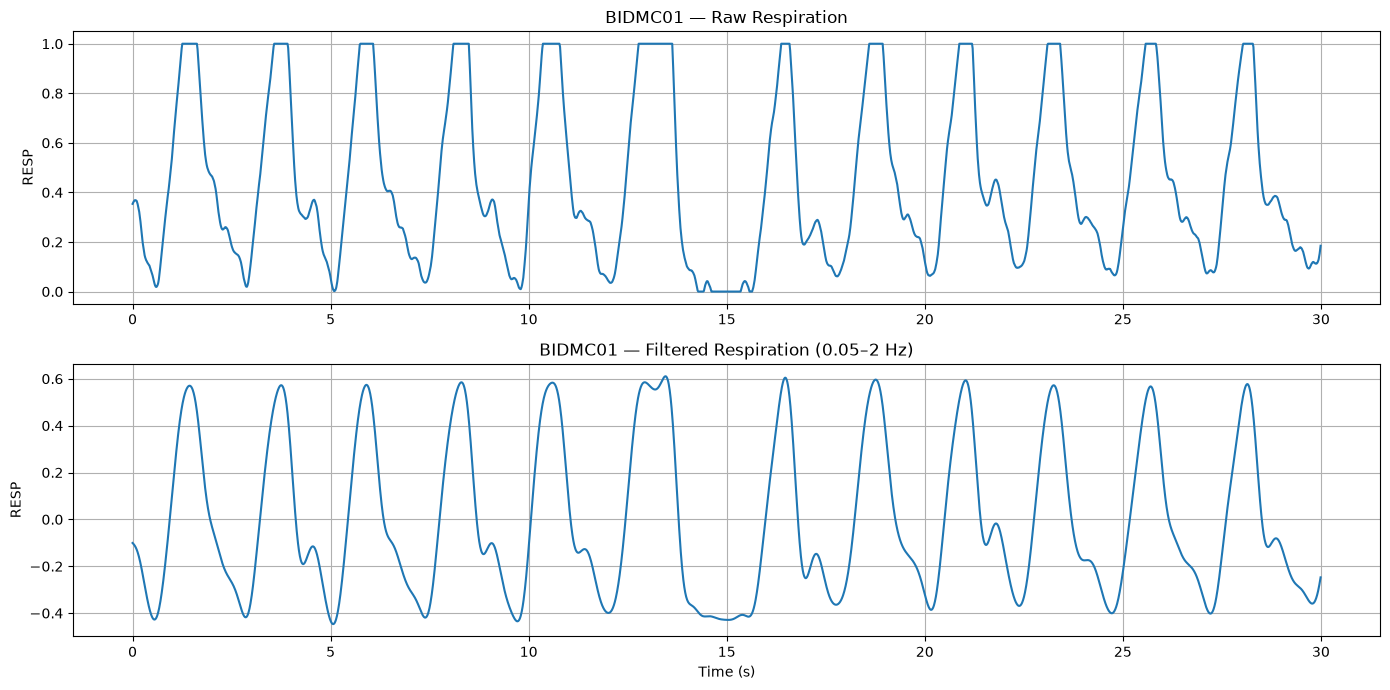


Displayed duration: 30.0 seconds

RESPIRATION FILTER VISUALIZATION COMPLETE


In [14]:
# Cell 13 — Visual validation of BIDMC respiration filtering

print("=" * 70)
print("BIDMC RESPIRATION FILTER VALIDATION")
print("=" * 70)

# Display the first 30 seconds
PLOT_DURATION_RESP = 30.0
plot_samples_resp = int(PLOT_DURATION_RESP * BIDMC_FS)

time_resp = np.arange(plot_samples_resp) / BIDMC_FS

plt.figure(figsize=(14, 7))

plt.subplot(2, 1, 1)
plt.plot(
    time_resp,
    resp_signal[:plot_samples_resp]
)
plt.ylabel("RESP")
plt.title("BIDMC01 — Raw Respiration")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(
    time_resp,
    resp_filtered[:plot_samples_resp]
)
plt.xlabel("Time (s)")
plt.ylabel("RESP")
plt.title("BIDMC01 — Filtered Respiration (0.05–2 Hz)")
plt.grid(True)

plt.tight_layout()
plt.show()

print()
print("Displayed duration:", PLOT_DURATION_RESP, "seconds")
print()
print("=" * 70)
print("RESPIRATION FILTER VISUALIZATION COMPLETE")
print("=" * 70)

In [15]:
# Cell 14 — Load BIDMC reference breath annotations

print("=" * 70)
print("LOADING BIDMC REFERENCE BREATH ANNOTATIONS")
print("=" * 70)

# Load manual breath annotations from PhysioNet
breath_annotations = wfdb.rdann(
    VALIDATION_RECORD,
    "breath",
    pn_dir="bidmc/1.0.0"
)

# Convert annotation sample locations to seconds
reference_breath_times = (
    breath_annotations.sample / BIDMC_FS
)

print()
print("Number of reference breath annotations:")
print(len(reference_breath_times))

print()
print("First 10 reference breath times (s):")
print(reference_breath_times[:10])

print()
print("Last 10 reference breath times (s):")
print(reference_breath_times[-10:])

print()
print("Annotation symbols:")
print(
    np.unique(
        breath_annotations.symbol,
        return_counts=True
    )
)

print()
print("=" * 70)
print("REFERENCE BREATH ANNOTATIONS LOADED")
print("=" * 70)

LOADING BIDMC REFERENCE BREATH ANNOTATIONS

Number of reference breath annotations:
335

First 10 reference breath times (s):
[ 1.488  1.504  3.768  3.8    5.888  5.968  8.288  8.328 10.568 10.584]

Last 10 reference breath times (s):
[463.944 466.648 466.808 469.624 469.816 472.56  472.616 475.304 475.4
 478.464]

Annotation symbols:
(array(['"'], dtype='<U1'), array([335]))

REFERENCE BREATH ANNOTATIONS LOADED


In [16]:
# Cell 15 — BIDMC respiration peak detection

print("=" * 70)
print("BIDMC RESPIRATION PEAK DETECTION")
print("=" * 70)

# Detect peaks in the filtered respiration signal
resp_peaks, resp_peak_properties = find_peaks(
    resp_filtered,
    distance=int(1.5 * BIDMC_FS),
    prominence=0.15
)

# Convert peak locations to seconds
resp_peak_times = resp_peaks / BIDMC_FS

print()
print("Detected respiration peaks:")
print(len(resp_peaks))

print()
print("Minimum peak distance:")
print("1.50 seconds")

print()
print("Peak prominence:")
print("0.15")

print()
print("First 10 detected respiration peak times (s):")
print(resp_peak_times[:10])

print()
print("Last 10 detected respiration peak times (s):")
print(resp_peak_times[-10:])

print()
print("=" * 70)
print("RESPIRATION PEAK DETECTION COMPLETE")
print("=" * 70)

BIDMC RESPIRATION PEAK DETECTION

Detected respiration peaks:
170

Minimum peak distance:
1.50 seconds

Peak prominence:
0.15

First 10 detected respiration peak times (s):
[ 1.44   3.752  5.904  8.304 10.6   13.456 16.48  18.76  21.032 23.256]

Last 10 detected respiration peak times (s):
[452.056 455.032 457.992 461.168 463.904 466.68  469.792 472.568 475.6
 478.448]

RESPIRATION PEAK DETECTION COMPLETE


RESPIRATION PEAK DETECTOR VS REFERENCE


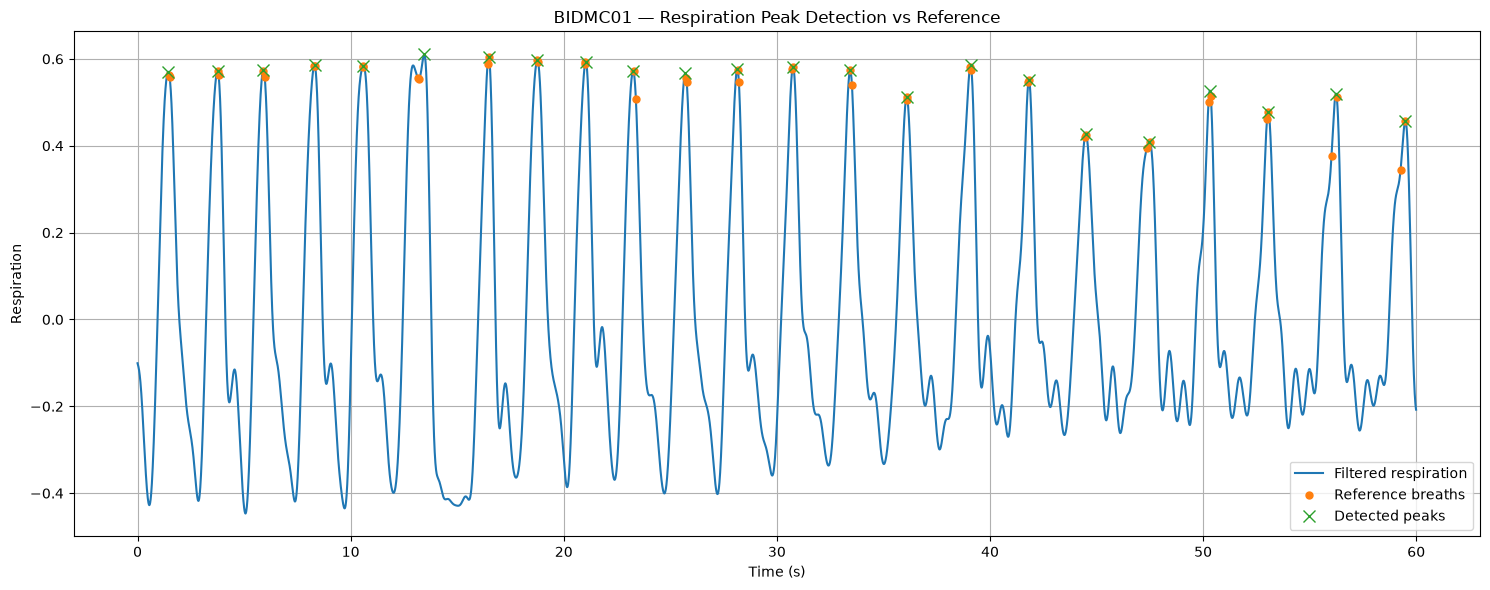


Reference breaths in first 60 s: 46
Detected peaks in first 60 s: 23

RESPIRATION COMPARISON COMPLETE


In [17]:
# Cell 16 — Visual comparison with BIDMC reference breaths

print("=" * 70)
print("RESPIRATION PEAK DETECTOR VS REFERENCE")
print("=" * 70)

# Display the first 60 seconds
PLOT_DURATION_BREATH = 60.0
plot_samples_breath = int(PLOT_DURATION_BREATH * BIDMC_FS)

time_breath = np.arange(plot_samples_breath) / BIDMC_FS

# Reference annotations inside displayed window
reference_mask = (
    reference_breath_times <= PLOT_DURATION_BREATH
)

# Detected peaks inside displayed window
detected_mask = (
    resp_peak_times <= PLOT_DURATION_BREATH
)

plt.figure(figsize=(15, 6))

plt.plot(
    time_breath,
    resp_filtered[:plot_samples_breath],
    label="Filtered respiration"
)

# Reference breath annotations
plt.plot(
    reference_breath_times[reference_mask],
    resp_filtered[
        np.clip(
            (reference_breath_times[reference_mask] * BIDMC_FS).astype(int),
            0,
            plot_samples_breath - 1
        )
    ],
    "o",
    markersize=5,
    label="Reference breaths"
)

# Our detected peaks
plt.plot(
    resp_peak_times[detected_mask],
    resp_filtered[resp_peaks[detected_mask]],
    "x",
    markersize=8,
    label="Detected peaks"
)

plt.xlabel("Time (s)")
plt.ylabel("Respiration")
plt.title(
    "BIDMC01 — Respiration Peak Detection vs Reference"
)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print()
print(
    "Reference breaths in first 60 s:",
    np.sum(reference_mask)
)

print(
    "Detected peaks in first 60 s:",
    np.sum(detected_mask)
)

print()
print("=" * 70)
print("RESPIRATION COMPARISON COMPLETE")
print("=" * 70)

In [18]:
# Cell 17 — Consolidate BIDMC dual-annotator breath references

print("=" * 70)
print("CONSOLIDATING BIDMC REFERENCE BREATHS")
print("=" * 70)

REFERENCE_CLUSTER_TOLERANCE = 0.5  # seconds

# Sort reference annotations
sorted_reference_times = np.sort(
    reference_breath_times
)

# Group nearby annotations
reference_breath_groups = []

current_group = [
    sorted_reference_times[0]
]

for time_point in sorted_reference_times[1:]:

    if (
        time_point - current_group[-1]
        <= REFERENCE_CLUSTER_TOLERANCE
    ):
        current_group.append(time_point)

    else:
        reference_breath_groups.append(
            current_group
        )

        current_group = [
            time_point
        ]

# Add final group
reference_breath_groups.append(
    current_group
)

# Represent each group by its mean annotation time
consolidated_reference_times = np.array([
    np.mean(group)
    for group in reference_breath_groups
])

print()
print("Original reference annotations:")
print(len(reference_breath_times))

print()
print("Consolidated reference breaths:")
print(len(consolidated_reference_times))

print()
print("Cluster tolerance:")
print(
    REFERENCE_CLUSTER_TOLERANCE,
    "seconds"
)

print()
print("First 10 consolidated reference times (s):")
print(
    consolidated_reference_times[:10]
)

print()
print("Last 10 consolidated reference times (s):")
print(
    consolidated_reference_times[-10:]
)

print()
print("=" * 70)
print("REFERENCE BREATH CONSOLIDATION COMPLETE")
print("=" * 70)

CONSOLIDATING BIDMC REFERENCE BREATHS

Original reference annotations:
335

Consolidated reference breaths:
170

Cluster tolerance:
0.5 seconds

First 10 consolidated reference times (s):
[ 1.496  3.784  5.928  8.308 10.576 13.172 16.452 18.776 21.004 23.328]

Last 10 consolidated reference times (s):
[452.072 454.868 457.98  461.1   463.864 466.728 469.72  472.588 475.352
 478.464]

REFERENCE BREATH CONSOLIDATION COMPLETE


In [19]:
# Cell 18 — Quantitative validation of respiration peak detection

print("=" * 70)
print("QUANTITATIVE RESPIRATION PEAK VALIDATION")
print("=" * 70)

MATCH_TOLERANCE = 0.5  # seconds

detected_times = np.asarray(resp_peak_times)
reference_times = np.asarray(consolidated_reference_times)

matched_reference = set()
matched_detected = set()
timing_errors = []

# Match each detected peak to the nearest unused reference breath
for detected_index, detected_time in enumerate(detected_times):

    time_differences = np.abs(
        reference_times - detected_time
    )

    # Do not reuse an already matched reference breath
    for reference_index in np.argsort(time_differences):

        if reference_index in matched_reference:
            continue

        difference = time_differences[reference_index]

        if difference <= MATCH_TOLERANCE:

            matched_detected.add(detected_index)
            matched_reference.add(reference_index)

            timing_errors.append(
                detected_time - reference_times[reference_index]
            )

            break

# Calculate metrics
true_positives = len(matched_detected)

false_positives = (
    len(detected_times) - true_positives
)

false_negatives = (
    len(reference_times) - true_positives
)

sensitivity = (
    true_positives / len(reference_times)
    if len(reference_times) > 0
    else np.nan
)

precision = (
    true_positives / len(detected_times)
    if len(detected_times) > 0
    else np.nan
)

timing_errors = np.asarray(timing_errors)

mean_timing_error = (
    np.mean(timing_errors)
    if len(timing_errors) > 0
    else np.nan
)

mean_absolute_timing_error = (
    np.mean(np.abs(timing_errors))
    if len(timing_errors) > 0
    else np.nan
)

print()
print("Reference breaths:")
print(len(reference_times))

print()
print("Detected respiration peaks:")
print(len(detected_times))

print()
print("Matching tolerance:")
print(f"{MATCH_TOLERANCE:.2f} seconds")

print()
print("True positives:")
print(true_positives)

print()
print("False positives:")
print(false_positives)

print()
print("False negatives:")
print(false_negatives)

print()
print("Sensitivity:")
print(f"{sensitivity * 100:.2f}%")

print()
print("Precision:")
print(f"{precision * 100:.2f}%")

print()
print("Mean timing error:")
print(f"{mean_timing_error:.4f} seconds")

print()
print("Mean absolute timing error:")
print(
    f"{mean_absolute_timing_error:.4f} seconds"
)

print()
print("=" * 70)
print("QUANTITATIVE RESPIRATION VALIDATION COMPLETE")
print("=" * 70)

QUANTITATIVE RESPIRATION PEAK VALIDATION

Reference breaths:
170

Detected respiration peaks:
170

Matching tolerance:
0.50 seconds

True positives:
170

False positives:
0

False negatives:
0

Sensitivity:
100.00%

Precision:
100.00%

Mean timing error:
0.0618 seconds

Mean absolute timing error:
0.0719 seconds

QUANTITATIVE RESPIRATION VALIDATION COMPLETE


In [20]:
# Cell 19 — Compact respiration validation summary

print("=" * 70)
print("BIDMC RESPIRATION VALIDATION SUMMARY")
print("=" * 70)

print()
print(f"Reference breaths       : {len(reference_times)}")
print(f"Detected peaks          : {len(detected_times)}")
print(f"True positives          : {true_positives}")
print(f"False positives         : {false_positives}")
print(f"False negatives         : {false_negatives}")

print()
print(f"Sensitivity             : {sensitivity * 100:.2f}%")
print(f"Precision               : {precision * 100:.2f}%")
print(f"Mean timing error       : {mean_timing_error:.4f} s")
print(
    f"Mean absolute timing error : "
    f"{mean_absolute_timing_error:.4f} s"
)

print()
print("Validation status:")

if (
    true_positives == len(reference_times)
    and false_positives == 0
    and false_negatives == 0
):
    print("PASS — all consolidated reference breaths matched")
else:
    print("REVIEW REQUIRED — unmatched breaths detected")

print()
print("=" * 70)
print("RESPIRATION VALIDATION SUMMARY COMPLETE")
print("=" * 70)

BIDMC RESPIRATION VALIDATION SUMMARY

Reference breaths       : 170
Detected peaks          : 170
True positives          : 170
False positives         : 0
False negatives         : 0

Sensitivity             : 100.00%
Precision               : 100.00%
Mean timing error       : 0.0618 s
Mean absolute timing error : 0.0719 s

Validation status:
PASS — all consolidated reference breaths matched

RESPIRATION VALIDATION SUMMARY COMPLETE


In [21]:
# Cell 20 — BIDMC respiration intervals and respiration rate

print("=" * 70)
print("BIDMC RESPIRATION RATE ANALYSIS")
print("=" * 70)

# Calculate intervals between consecutive respiration peaks
resp_intervals = np.diff(resp_peak_times)

# Convert intervals to respiration rate
# breaths per minute = 60 / interval in seconds
respiration_rate = 60.0 / resp_intervals

# Time associated with each respiration interval
resp_rate_times = resp_peak_times[1:]

print()
print("Number of respiration intervals:")
print(len(resp_intervals))

print()
print("Respiration interval statistics:")
print(f"Mean : {np.mean(resp_intervals):.4f} s")
print(f"Min  : {np.min(resp_intervals):.4f} s")
print(f"Max  : {np.max(resp_intervals):.4f} s")
print(f"Std  : {np.std(resp_intervals):.4f} s")

print()
print("Respiration-rate statistics:")
print(
    f"Mean : {np.mean(respiration_rate):.2f} breaths/min"
)
print(
    f"Min  : {np.min(respiration_rate):.2f} breaths/min"
)
print(
    f"Max  : {np.max(respiration_rate):.2f} breaths/min"
)
print(
    f"Std  : {np.std(respiration_rate):.2f} breaths/min"
)

print()
print("NaN counts:")
print(
    "Respiration intervals :",
    np.isnan(resp_intervals).sum()
)
print(
    "Respiration rate      :",
    np.isnan(respiration_rate).sum()
)

print()
print("=" * 70)
print("RESPIRATION RATE ANALYSIS COMPLETE")
print("=" * 70)

BIDMC RESPIRATION RATE ANALYSIS

Number of respiration intervals:
169

Respiration interval statistics:
Mean : 2.8225 s
Min  : 2.1520 s
Max  : 3.5920 s
Std  : 0.2235 s

Respiration-rate statistics:
Mean : 21.39 breaths/min
Min  : 16.70 breaths/min
Max  : 27.88 breaths/min
Std  : 1.75 breaths/min

NaN counts:
Respiration intervals : 0
Respiration rate      : 0

RESPIRATION RATE ANALYSIS COMPLETE


In [22]:
# Cell 21 — Inspect BIDMC reference numerical signals

print("=" * 70)
print("BIDMC REFERENCE NUMERICAL SIGNALS")
print("=" * 70)

# Load the BIDMC numerical reference record
bidmc_numerics = wfdb.rdrecord(
    VALIDATION_RECORD + "n",
    pn_dir="bidmc/1.0.0"
)

print()
print("Numerical record:")
print(bidmc_numerics.record_name)

print()
print("Sampling frequency:")
print(bidmc_numerics.fs, "Hz")

print()
print("Number of samples:")
print(bidmc_numerics.sig_len)

print()
print("Channel names:")

for i, name in enumerate(bidmc_numerics.sig_name):
    print(
        f"Channel {i}: {repr(name)}"
    )

print()
print("Signal units:")

for i, unit in enumerate(bidmc_numerics.units):
    print(
        f"Channel {i}: {repr(unit)}"
    )

print()
print("Signal shape:")
print(bidmc_numerics.p_signal.shape)

print()
print("=" * 70)
print("REFERENCE NUMERICAL SIGNAL INSPECTION COMPLETE")
print("=" * 70)

BIDMC REFERENCE NUMERICAL SIGNALS

Numerical record:
bidmc01n

Sampling frequency:
1 Hz

Number of samples:
481

Channel names:
Channel 0: 'HR,'
Channel 1: 'PULSE,'
Channel 2: 'RESP,'
Channel 3: 'SpO2,'

Signal units:
Channel 0: 'bpm'
Channel 1: 'bpm'
Channel 2: 'pm'
Channel 3: '%'

Signal shape:
(481, 4)

REFERENCE NUMERICAL SIGNAL INSPECTION COMPLETE


In [23]:
# Cell 22 — Extract BIDMC reference respiration rate

print("=" * 70)
print("BIDMC REFERENCE RESPIRATION RATE")
print("=" * 70)

# RESP reference numerical channel confirmed in Cell 21
REFERENCE_RESP_CHANNEL = 2

reference_resp_rate = (
    bidmc_numerics.p_signal[
        :,
        REFERENCE_RESP_CHANNEL
    ]
)

# Numerical reference time axis
reference_resp_time = (
    np.arange(len(reference_resp_rate))
    / bidmc_numerics.fs
)

print()
print("Reference respiration channel:")
print(
    bidmc_numerics.sig_name[
        REFERENCE_RESP_CHANNEL
    ]
)

print()
print("Reference respiration unit:")
print(
    bidmc_numerics.units[
        REFERENCE_RESP_CHANNEL
    ]
)

print()
print("Number of reference respiration samples:")
print(len(reference_resp_rate))

print()
print("Reference respiration-rate statistics:")

print(
    f"Mean : {np.nanmean(reference_resp_rate):.2f} breaths/min"
)

print(
    f"Min  : {np.nanmin(reference_resp_rate):.2f} breaths/min"
)

print(
    f"Max  : {np.nanmax(reference_resp_rate):.2f} breaths/min"
)

print(
    f"Std  : {np.nanstd(reference_resp_rate):.2f} breaths/min"
)

print()
print("NaN count:")
print(np.isnan(reference_resp_rate).sum())

print()
print("First 10 reference respiration values:")
print(reference_resp_rate[:10])

print()
print("=" * 70)
print("REFERENCE RESPIRATION RATE EXTRACTION COMPLETE")
print("=" * 70)

BIDMC REFERENCE RESPIRATION RATE

Reference respiration channel:
RESP,

Reference respiration unit:
pm

Number of reference respiration samples:
481

Reference respiration-rate statistics:
Mean : 21.44 breaths/min
Min  : 20.00 breaths/min
Max  : 26.00 breaths/min
Std  : 1.29 breaths/min

NaN count:
0

First 10 reference respiration values:
[24.99996956 24.99996956 24.99996956 26.0000306  26.0000306  26.0000306
 26.0000306  26.0000306  26.0000306  26.0000306 ]

REFERENCE RESPIRATION RATE EXTRACTION COMPLETE


In [24]:
# Cell 23 — Compare waveform-derived and reference respiration rates

print("=" * 70)
print("BIDMC RESPIRATION-RATE COMPARISON")
print("=" * 70)

# Interpolate our waveform-derived respiration rate
# onto the 1 Hz reference time points.
derived_resp_rate_at_reference = np.interp(
    reference_resp_time,
    resp_rate_times,
    respiration_rate
)

# Only compare points where both signals are valid
valid_mask = (
    np.isfinite(
        derived_resp_rate_at_reference
    )
    &
    np.isfinite(
        reference_resp_rate
    )
)

derived_valid = (
    derived_resp_rate_at_reference[
        valid_mask
    ]
)

reference_valid = (
    reference_resp_rate[
        valid_mask
    ]
)

# Calculate comparison metrics
resp_rate_errors = (
    derived_valid - reference_valid
)

mean_error = np.mean(resp_rate_errors)

mean_absolute_error = np.mean(
    np.abs(resp_rate_errors)
)

rmse = np.sqrt(
    np.mean(
        resp_rate_errors ** 2
    )
)

correlation = np.corrcoef(
    derived_valid,
    reference_valid
)[0, 1]

print()
print("Valid comparison samples:")
print(len(derived_valid))

print()
print("Derived respiration rate:")
print(
    f"Mean : {np.mean(derived_valid):.2f} breaths/min"
)

print()
print("Reference respiration rate:")
print(
    f"Mean : {np.mean(reference_valid):.2f} breaths/min"
)

print()
print("Comparison metrics:")

print(
    f"Mean error           : "
    f"{mean_error:.4f} breaths/min"
)

print(
    f"Mean absolute error  : "
    f"{mean_absolute_error:.4f} breaths/min"
)

print(
    f"RMSE                 : "
    f"{rmse:.4f} breaths/min"
)

print(
    f"Correlation          : "
    f"{correlation:.4f}"
)

print()
print("NaN / Inf check:")
print(
    "Derived:",
    np.isfinite(derived_valid).all()
)
print(
    "Reference:",
    np.isfinite(reference_valid).all()
)

print()
print("=" * 70)
print("RESPIRATION-RATE COMPARISON COMPLETE")
print("=" * 70)

BIDMC RESPIRATION-RATE COMPARISON

Valid comparison samples:
481

Derived respiration rate:
Mean : 21.33 breaths/min

Reference respiration rate:
Mean : 21.44 breaths/min

Comparison metrics:
Mean error           : -0.1055 breaths/min
Mean absolute error  : 1.0514 breaths/min
RMSE                 : 1.3367 breaths/min
Correlation          : 0.5725

NaN / Inf check:
Derived: True
Reference: True

RESPIRATION-RATE COMPARISON COMPLETE


In [25]:
# Cell 24 — BIDMC PPG bandpass filtering

print("=" * 70)
print("BIDMC PPG BANDPASS FILTERING")
print("=" * 70)

# PPG filter configuration
PPG_LOW_CUTOFF = 0.5
PPG_HIGH_CUTOFF = 8.0
PPG_FILTER_ORDER = 4

# Design Butterworth bandpass filter using SOS
ppg_sos = butter(
    PPG_FILTER_ORDER,
    [PPG_LOW_CUTOFF, PPG_HIGH_CUTOFF],
    btype="bandpass",
    fs=BIDMC_FS,
    output="sos"
)

# Apply zero-phase filtering
ppg_filtered = sosfiltfilt(
    ppg_sos,
    ppg_signal
)

print()
print("Filter type:")
print("Butterworth bandpass")

print()
print("Low cutoff:")
print(PPG_LOW_CUTOFF, "Hz")

print()
print("High cutoff:")
print(PPG_HIGH_CUTOFF, "Hz")

print()
print("Filter order:")
print(PPG_FILTER_ORDER)

print()
print("Original PPG range:")
print(
    f"{np.min(ppg_signal):.6f} to "
    f"{np.max(ppg_signal):.6f}"
)

print()
print("Filtered PPG range:")
print(
    f"{np.min(ppg_filtered):.6f} to "
    f"{np.max(ppg_filtered):.6f}"
)

print()
print("NaN count after filtering:")
print(np.isnan(ppg_filtered).sum())

print()
print("=" * 70)
print("PPG BANDPASS FILTERING COMPLETE")
print("=" * 70)

BIDMC PPG BANDPASS FILTERING

Filter type:
Butterworth bandpass

Low cutoff:
0.5 Hz

High cutoff:
8.0 Hz

Filter order:
4

Original PPG range:
0.223852 to 0.697948

Filtered PPG range:
-0.096034 to 0.213295

NaN count after filtering:
0

PPG BANDPASS FILTERING COMPLETE


BIDMC PPG FILTER VALIDATION


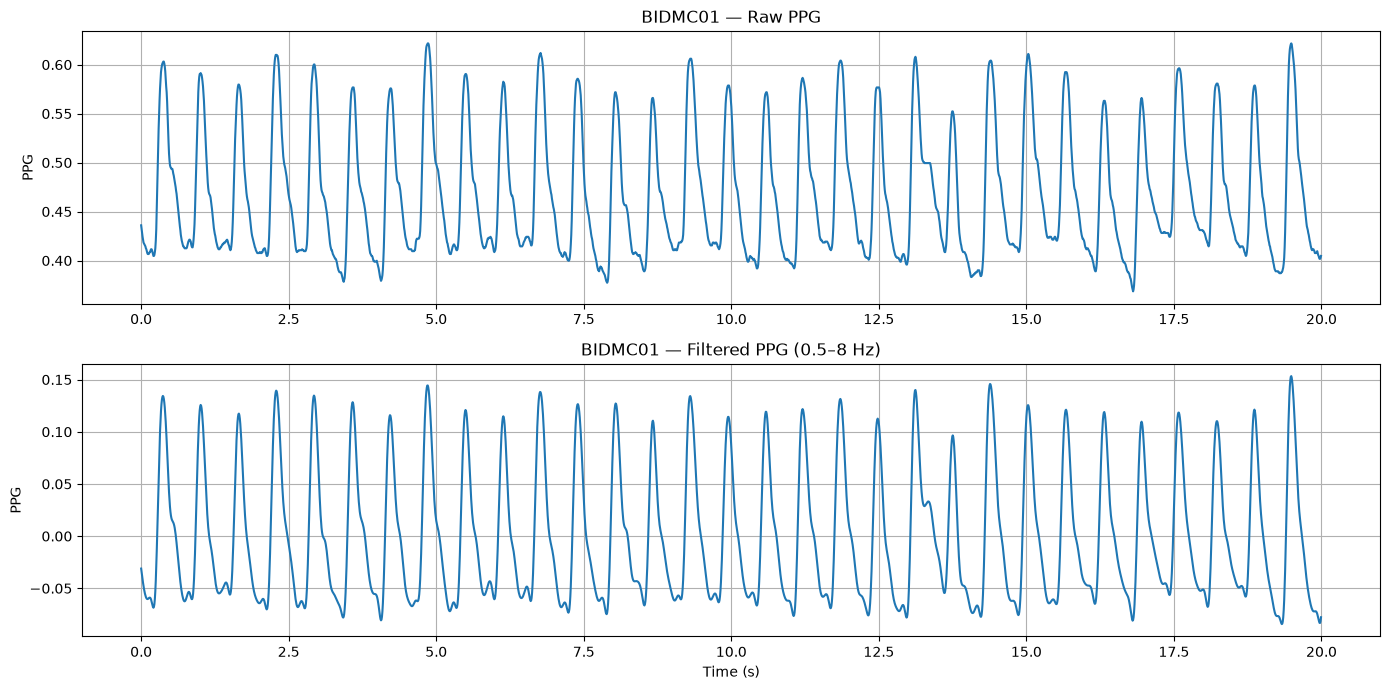


Displayed duration: 20.0 seconds

PPG FILTER VISUALIZATION COMPLETE


In [26]:
# Cell 25 — Visual validation of BIDMC PPG filtering

print("=" * 70)
print("BIDMC PPG FILTER VALIDATION")
print("=" * 70)

# Display the first 20 seconds
PLOT_DURATION_PPG = 20.0
plot_samples_ppg = int(
    PLOT_DURATION_PPG * BIDMC_FS
)

time_ppg = (
    np.arange(plot_samples_ppg)
    / BIDMC_FS
)

plt.figure(figsize=(14, 7))

plt.subplot(2, 1, 1)

plt.plot(
    time_ppg,
    ppg_signal[:plot_samples_ppg]
)

plt.ylabel("PPG")
plt.title(
    "BIDMC01 — Raw PPG"
)

plt.grid(True)


plt.subplot(2, 1, 2)

plt.plot(
    time_ppg,
    ppg_filtered[:plot_samples_ppg]
)

plt.xlabel("Time (s)")
plt.ylabel("PPG")

plt.title(
    "BIDMC01 — Filtered PPG (0.5–8 Hz)"
)

plt.grid(True)

plt.tight_layout()
plt.show()

print()
print(
    "Displayed duration:",
    PLOT_DURATION_PPG,
    "seconds"
)

print()
print("=" * 70)
print("PPG FILTER VISUALIZATION COMPLETE")
print("=" * 70)

In [27]:
# Cell 26 — BIDMC PPG pulse-peak detection

print("=" * 70)
print("BIDMC PPG PULSE-PEAK DETECTION")
print("=" * 70)

# Detect pulse peaks from filtered PPG
ppg_peaks, ppg_peak_properties = find_peaks(
    ppg_filtered,
    distance=int(0.30 * BIDMC_FS),
    prominence=0.03
)

# Convert peak locations to seconds
ppg_peak_times = ppg_peaks / BIDMC_FS

print()
print("Detected PPG pulse peaks:")
print(len(ppg_peaks))

print()
print("Minimum peak distance:")
print("0.30 seconds")

print()
print("Peak prominence:")
print("0.03")

print()
print("First 10 PPG peak times (s):")
print(ppg_peak_times[:10])

print()
print("Last 10 PPG peak times (s):")
print(ppg_peak_times[-10:])

print()
print("=" * 70)
print("PPG PULSE-PEAK DETECTION COMPLETE")
print("=" * 70)

BIDMC PPG PULSE-PEAK DETECTION

Detected PPG pulse peaks:
717

Minimum peak distance:
0.30 seconds

Peak prominence:
0.03

First 10 PPG peak times (s):
[0.368 1.008 1.656 2.288 2.928 3.584 4.216 4.856 5.496 6.136]

Last 10 PPG peak times (s):
[473.464 474.128 474.808 475.472 476.136 476.8   477.48  478.144 478.808
 479.472]

PPG PULSE-PEAK DETECTION COMPLETE


In [28]:
# Cell 27 — BIDMC PPG-derived pulse rate

print("=" * 70)
print("BIDMC PPG PULSE-RATE ANALYSIS")
print("=" * 70)

# Calculate intervals between consecutive PPG pulse peaks
ppg_intervals = np.diff(ppg_peak_times)

# Convert pulse intervals to beats per minute
ppg_pulse_rate = 60.0 / ppg_intervals

# Time associated with each pulse interval
ppg_rate_times = ppg_peak_times[1:]

print()
print("Number of PPG pulse intervals:")
print(len(ppg_intervals))

print()
print("PPG pulse-interval statistics:")
print(f"Mean : {np.mean(ppg_intervals):.4f} s")
print(f"Min  : {np.min(ppg_intervals):.4f} s")
print(f"Max  : {np.max(ppg_intervals):.4f} s")
print(f"Std  : {np.std(ppg_intervals):.4f} s")

print()
print("PPG-derived pulse-rate statistics:")
print(
    f"Mean : {np.mean(ppg_pulse_rate):.2f} BPM"
)
print(
    f"Min  : {np.min(ppg_pulse_rate):.2f} BPM"
)
print(
    f"Max  : {np.max(ppg_pulse_rate):.2f} BPM"
)
print(
    f"Std  : {np.std(ppg_pulse_rate):.2f} BPM"
)

print()
print("NaN counts:")
print(
    "PPG intervals :",
    np.isnan(ppg_intervals).sum()
)
print(
    "PPG pulse rate:",
    np.isnan(ppg_pulse_rate).sum()
)

print()
print("=" * 70)
print("PPG PULSE-RATE ANALYSIS COMPLETE")
print("=" * 70)

BIDMC PPG PULSE-RATE ANALYSIS

Number of PPG pulse intervals:
716

PPG pulse-interval statistics:
Mean : 0.6691 s
Min  : 0.4480 s
Max  : 3.2160 s
Std  : 0.1461 s

PPG-derived pulse-rate statistics:
Mean : 90.90 BPM
Min  : 18.66 BPM
Max  : 133.93 BPM
Std  : 6.40 BPM

NaN counts:
PPG intervals : 0
PPG pulse rate: 0

PPG PULSE-RATE ANALYSIS COMPLETE


BIDMC PPG PULSE-PEAK VALIDATION


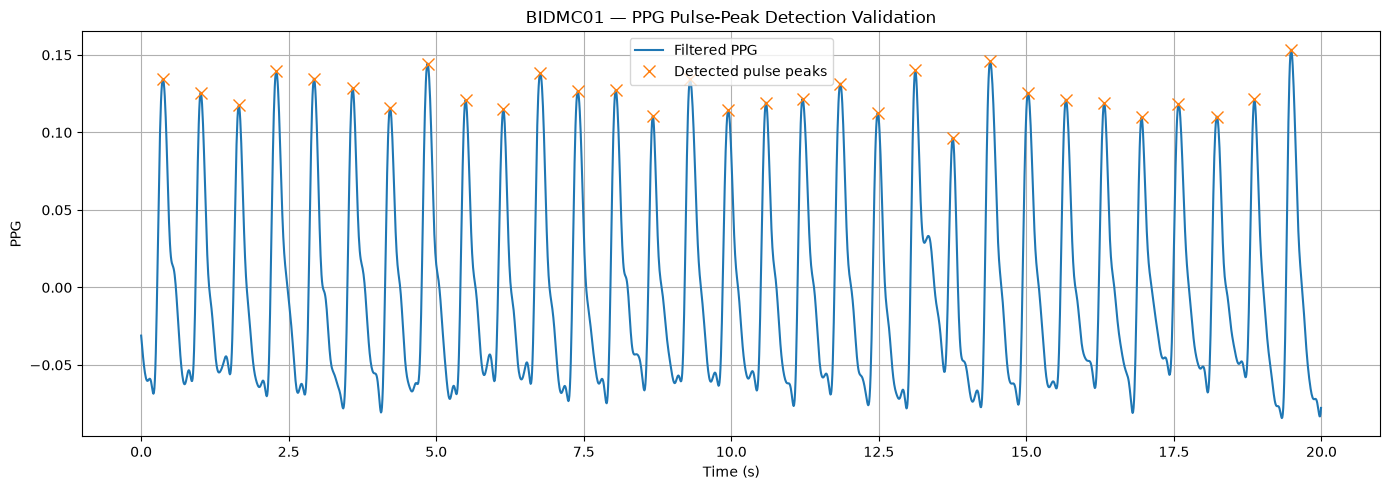


Displayed duration: 20.0 seconds

Detected peaks in displayed interval: 31

PPG PULSE-PEAK VISUAL VALIDATION COMPLETE


In [29]:
# Cell 28 — Visual validation of BIDMC PPG pulse peaks

print("=" * 70)
print("BIDMC PPG PULSE-PEAK VALIDATION")
print("=" * 70)

# Display the first 20 seconds
PLOT_DURATION_PPG_PEAKS = 20.0

plot_samples_ppg_peaks = int(
    PLOT_DURATION_PPG_PEAKS * BIDMC_FS
)

time_ppg_peaks = (
    np.arange(plot_samples_ppg_peaks)
    / BIDMC_FS
)

# Select detected peaks inside the displayed interval
ppg_peak_mask = (
    ppg_peak_times <= PLOT_DURATION_PPG_PEAKS
)

plt.figure(figsize=(14, 5))

plt.plot(
    time_ppg_peaks,
    ppg_filtered[:plot_samples_ppg_peaks],
    label="Filtered PPG"
)

plt.plot(
    ppg_peak_times[ppg_peak_mask],
    ppg_filtered[
        ppg_peaks[ppg_peak_mask]
    ],
    "x",
    markersize=8,
    label="Detected pulse peaks"
)

plt.xlabel("Time (s)")
plt.ylabel("PPG")
plt.title(
    "BIDMC01 — PPG Pulse-Peak Detection Validation"
)

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print()
print(
    "Displayed duration:",
    PLOT_DURATION_PPG_PEAKS,
    "seconds"
)

print()
print(
    "Detected peaks in displayed interval:",
    np.sum(ppg_peak_mask)
)

print()
print("=" * 70)
print("PPG PULSE-PEAK VISUAL VALIDATION COMPLETE")
print("=" * 70)

In [30]:
# Cell 29 — Compare PPG-derived pulse rate with BIDMC reference PULSE

print("=" * 70)
print("BIDMC PPG PULSE-RATE COMPARISON")
print("=" * 70)

# PULSE reference numerical channel confirmed from Cell 21
REFERENCE_PULSE_CHANNEL = 1

reference_pulse_rate = (
    bidmc_numerics.p_signal[
        :,
        REFERENCE_PULSE_CHANNEL
    ]
)

# Reference pulse time axis
reference_pulse_time = (
    np.arange(len(reference_pulse_rate))
    / bidmc_numerics.fs
)

# Interpolate PPG-derived pulse rate
# onto the 1 Hz reference time points
derived_pulse_rate_at_reference = np.interp(
    reference_pulse_time,
    ppg_rate_times,
    ppg_pulse_rate
)

# Keep only valid comparison points
valid_pulse_mask = (
    np.isfinite(
        derived_pulse_rate_at_reference
    )
    &
    np.isfinite(
        reference_pulse_rate
    )
)

derived_pulse_valid = (
    derived_pulse_rate_at_reference[
        valid_pulse_mask
    ]
)

reference_pulse_valid = (
    reference_pulse_rate[
        valid_pulse_mask
    ]
)

# Calculate errors
pulse_rate_errors = (
    derived_pulse_valid
    - reference_pulse_valid
)

pulse_mean_error = np.mean(
    pulse_rate_errors
)

pulse_mean_absolute_error = np.mean(
    np.abs(pulse_rate_errors)
)

pulse_rmse = np.sqrt(
    np.mean(
        pulse_rate_errors ** 2
    )
)

pulse_correlation = np.corrcoef(
    derived_pulse_valid,
    reference_pulse_valid
)[0, 1]

print()
print("Reference PULSE channel:")
print(
    bidmc_numerics.sig_name[
        REFERENCE_PULSE_CHANNEL
    ]
)

print()
print("Reference pulse unit:")
print(
    bidmc_numerics.units[
        REFERENCE_PULSE_CHANNEL
    ]
)

print()
print("Valid comparison samples:")
print(len(derived_pulse_valid))

print()
print("Derived PPG pulse rate:")
print(
    f"Mean : "
    f"{np.mean(derived_pulse_valid):.2f} BPM"
)

print()
print("Reference PULSE rate:")
print(
    f"Mean : "
    f"{np.mean(reference_pulse_valid):.2f} BPM"
)

print()
print("Comparison metrics:")

print(
    f"Mean error          : "
    f"{pulse_mean_error:.4f} BPM"
)

print(
    f"Mean absolute error : "
    f"{pulse_mean_absolute_error:.4f} BPM"
)

print(
    f"RMSE                : "
    f"{pulse_rmse:.4f} BPM"
)

print(
    f"Correlation         : "
    f"{pulse_correlation:.4f}"
)

print()
print("NaN / Inf check:")

print(
    "Derived:",
    np.isfinite(
        derived_pulse_valid
    ).all()
)

print(
    "Reference:",
    np.isfinite(
        reference_pulse_valid
    ).all()
)

print()
print("=" * 70)
print("PPG PULSE-RATE COMPARISON COMPLETE")
print("=" * 70)

BIDMC PPG PULSE-RATE COMPARISON

Reference PULSE channel:
PULSE,

Reference pulse unit:
bpm

Valid comparison samples:
468

Derived PPG pulse rate:
Mean : 89.96 BPM

Reference PULSE rate:
Mean : 91.01 BPM

Comparison metrics:
Mean error          : -1.0476 BPM
Mean absolute error : 2.5980 BPM
RMSE                : 9.0304 BPM
Correlation         : 0.0529

NaN / Inf check:
Derived: True
Reference: True

PPG PULSE-RATE COMPARISON COMPLETE


In [31]:
# Cell 30 — Diagnose PPG pulse-rate comparison errors

print("=" * 70)
print("PPG PULSE-RATE ERROR DIAGNOSTICS")
print("=" * 70)

# Calculate absolute errors
absolute_pulse_errors = np.abs(
    pulse_rate_errors
)

# Identify the largest errors
largest_error_indices = np.argsort(
    absolute_pulse_errors
)[-10:][::-1]

print()
print("Largest 10 absolute pulse-rate errors:")
print()

for rank, index in enumerate(
    largest_error_indices,
    start=1
):

    print(
        f"{rank:2d}. "
        f"Time = "
        f"{reference_pulse_time[valid_pulse_mask][index]:8.2f} s | "
        f"Derived = "
        f"{derived_pulse_valid[index]:7.2f} BPM | "
        f"Reference = "
        f"{reference_pulse_valid[index]:7.2f} BPM | "
        f"Error = "
        f"{pulse_rate_errors[index]:7.2f} BPM"
    )

print()
print("Error distribution:")

print(
    "Absolute error <= 1 BPM :",
    np.sum(
        absolute_pulse_errors <= 1.0
    )
)

print(
    "Absolute error <= 2 BPM :",
    np.sum(
        absolute_pulse_errors <= 2.0
    )
)

print(
    "Absolute error <= 5 BPM :",
    np.sum(
        absolute_pulse_errors <= 5.0
    )
)

print(
    "Absolute error > 5 BPM  :",
    np.sum(
        absolute_pulse_errors > 5.0
    )
)

print()
print("PPG interval outliers:")

print(
    "Intervals > 1.5 s:",
    np.sum(ppg_intervals > 1.5)
)

print(
    "Intervals > 2.0 s:",
    np.sum(ppg_intervals > 2.0)
)

print(
    "Maximum PPG interval:",
    f"{np.max(ppg_intervals):.4f} s"
)

print()
print("=" * 70)
print("PPG PULSE-RATE ERROR DIAGNOSTICS COMPLETE")
print("=" * 70)

PPG PULSE-RATE ERROR DIAGNOSTICS

Largest 10 absolute pulse-rate errors:

 1. Time =    95.00 s | Derived =   18.93 BPM | Reference =   91.00 BPM | Error =  -72.07 BPM
 2. Time =    96.00 s | Derived =   20.15 BPM | Reference =   91.00 BPM | Error =  -70.85 BPM
 3. Time =    97.00 s | Derived =   21.38 BPM | Reference =   91.00 BPM | Error =  -69.62 BPM
 4. Time =    98.00 s | Derived =   29.92 BPM | Reference =   91.00 BPM | Error =  -61.08 BPM
 5. Time =   102.00 s | Derived =   30.63 BPM | Reference =   91.00 BPM | Error =  -60.37 BPM
 6. Time =   103.00 s | Derived =   31.30 BPM | Reference =   91.00 BPM | Error =  -59.70 BPM
 7. Time =    94.00 s | Derived =   35.45 BPM | Reference =   91.00 BPM | Error =  -55.55 BPM
 8. Time =   101.00 s | Derived =   46.37 BPM | Reference =   91.00 BPM | Error =  -44.63 BPM
 9. Time =   415.00 s | Derived =  133.33 BPM | Reference =   90.00 BPM | Error =   43.33 BPM
10. Time =    93.00 s | Derived =   57.08 BPM | Reference =   91.00 BPM | Error 

PPG OUTLIER REGION INSPECTION


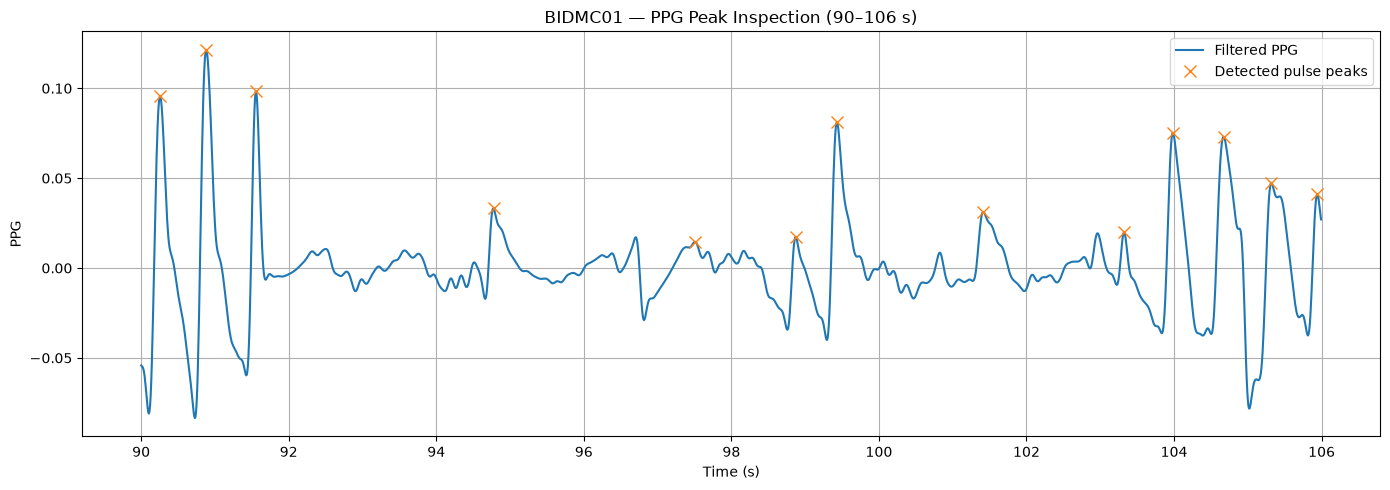


Region: 90–106 s
Detected peaks: 13


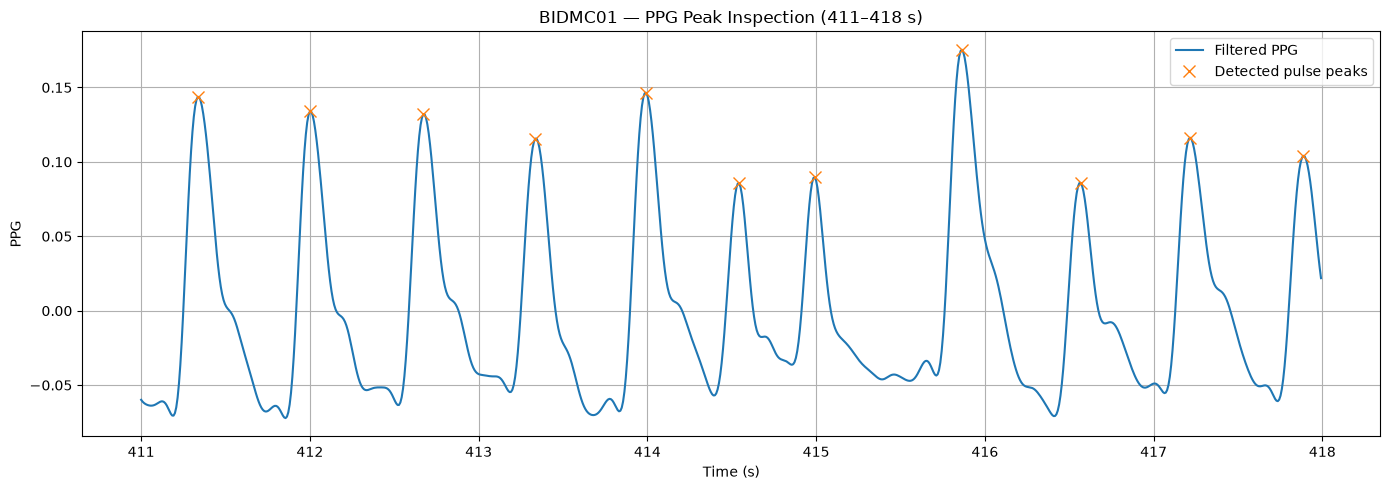


Region: 411–418 s
Detected peaks: 11

PPG OUTLIER REGION INSPECTION COMPLETE


In [32]:
# Cell 31 — Visual inspection of PPG pulse-rate outlier regions

print("=" * 70)
print("PPG OUTLIER REGION INSPECTION")
print("=" * 70)

# Regions identified by Cell 30
OUTLIER_REGIONS = [
    (90.0, 106.0),
    (411.0, 418.0)
]

for region_start, region_end in OUTLIER_REGIONS:

    start_sample = int(
        region_start * BIDMC_FS
    )

    end_sample = int(
        region_end * BIDMC_FS
    )

    region_time = (
        np.arange(
            start_sample,
            end_sample
        )
        / BIDMC_FS
    )

    region_peak_mask = (
        (ppg_peak_times >= region_start)
        &
        (ppg_peak_times <= region_end)
    )

    plt.figure(figsize=(14, 5))

    plt.plot(
        region_time,
        ppg_filtered[
            start_sample:end_sample
        ],
        label="Filtered PPG"
    )

    plt.plot(
        ppg_peak_times[region_peak_mask],
        ppg_filtered[
            ppg_peaks[region_peak_mask]
        ],
        "x",
        markersize=9,
        label="Detected pulse peaks"
    )

    plt.xlabel("Time (s)")
    plt.ylabel("PPG")
    plt.title(
        f"BIDMC01 — PPG Peak Inspection "
        f"({region_start:.0f}–{region_end:.0f} s)"
    )

    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

    print()
    print(
        f"Region: {region_start:.0f}–{region_end:.0f} s"
    )

    print(
        "Detected peaks:",
        np.sum(region_peak_mask)
    )

print()
print("=" * 70)
print("PPG OUTLIER REGION INSPECTION COMPLETE")
print("=" * 70)

In [33]:
# Cell 32 — Diagnose long PPG gaps using ECG comparison

print("=" * 70)
print("PPG GAP DIAGNOSTICS WITH ECG COMPARISON")
print("=" * 70)

# Identify unusually long PPG intervals
PPG_GAP_THRESHOLD = 1.5  # seconds

long_gap_indices = np.where(
    ppg_intervals > PPG_GAP_THRESHOLD
)[0]

print()
print(
    "PPG intervals greater than",
    PPG_GAP_THRESHOLD,
    "seconds:",
    len(long_gap_indices)
)

print()

for index in long_gap_indices:

    gap_start = ppg_peak_times[index]
    gap_end = ppg_peak_times[index + 1]
    gap_duration = ppg_intervals[index]

    # ECG heart-rate values during the same time interval
    ecg_gap_mask = (
        (hr_times >= gap_start)
        &
        (hr_times <= gap_end)
    )

    ecg_hr_in_gap = heart_rate[
        ecg_gap_mask
    ]

    print("-" * 70)

    print(
        f"PPG gap: "
        f"{gap_start:.3f}–{gap_end:.3f} s"
    )

    print(
        f"Gap duration: "
        f"{gap_duration:.3f} s"
    )

    print(
        f"Equivalent PPG rate: "
        f"{60.0 / gap_duration:.2f} BPM"
    )

    if len(ecg_hr_in_gap) > 0:

        print(
            f"ECG HR during gap: "
            f"{np.mean(ecg_hr_in_gap):.2f} BPM"
        )

        print(
            f"ECG HR range: "
            f"{np.min(ecg_hr_in_gap):.2f}–"
            f"{np.max(ecg_hr_in_gap):.2f} BPM"
        )

    else:

        print(
            "ECG HR during gap: "
            "No ECG intervals available"
        )

print()
print("=" * 70)
print("PPG GAP DIAGNOSTICS COMPLETE")
print("=" * 70)

PPG GAP DIAGNOSTICS WITH ECG COMPARISON

PPG intervals greater than 1.5 seconds: 4

----------------------------------------------------------------------
PPG gap: 91.560–94.776 s
Gap duration: 3.216 s
Equivalent PPG rate: 18.66 BPM
ECG HR during gap: 94.79 BPM
ECG HR range: 74.26–110.29 BPM
----------------------------------------------------------------------
PPG gap: 94.776–97.504 s
Gap duration: 2.728 s
Equivalent PPG rate: 21.99 BPM
ECG HR during gap: 88.25 BPM
ECG HR range: 74.26–92.59 BPM
----------------------------------------------------------------------
PPG gap: 99.432–101.416 s
Gap duration: 1.984 s
Equivalent PPG rate: 30.24 BPM
ECG HR during gap: 92.22 BPM
ECG HR range: 91.46–92.59 BPM
----------------------------------------------------------------------
PPG gap: 101.416–103.320 s
Gap duration: 1.904 s
Equivalent PPG rate: 31.51 BPM
ECG HR during gap: 91.84 BPM
ECG HR range: 91.46–92.59 BPM

PPG GAP DIAGNOSTICS COMPLETE


In [34]:
# Cell 33 — Quantify PPG signal-quality gaps

print("=" * 70)
print("PPG SIGNAL-QUALITY GAP SUMMARY")
print("=" * 70)

# Define a conservative interval-quality threshold
PPG_QUALITY_INTERVAL_THRESHOLD = 1.5  # seconds

# Identify intervals considered unreliable
ppg_quality_bad_mask = (
    ppg_intervals >
    PPG_QUALITY_INTERVAL_THRESHOLD
)

ppg_quality_good_mask = (
    ~ppg_quality_bad_mask
)

# Count intervals
total_ppg_intervals = len(ppg_intervals)

good_ppg_intervals = np.sum(
    ppg_quality_good_mask
)

bad_ppg_intervals = np.sum(
    ppg_quality_bad_mask
)

# Calculate percentages
good_percentage = (
    good_ppg_intervals
    / total_ppg_intervals
    * 100
)

bad_percentage = (
    bad_ppg_intervals
    / total_ppg_intervals
    * 100
)

print()
print("Total PPG intervals:")
print(total_ppg_intervals)

print()
print("Good-quality intervals:")
print(good_ppg_intervals)

print()
print("Long-gap / low-quality intervals:")
print(bad_ppg_intervals)

print()
print(
    f"Good-quality percentage: "
    f"{good_percentage:.2f}%"
)

print(
    f"Low-quality percentage: "
    f"{bad_percentage:.2f}%"
)

print()
print("Quality rule:")
print(
    f"PPG interval <= "
    f"{PPG_QUALITY_INTERVAL_THRESHOLD:.1f} s "
    f"→ usable"
)

print(
    f"PPG interval > "
    f"{PPG_QUALITY_INTERVAL_THRESHOLD:.1f} s "
    f"→ flag as low quality"
)

print()
print("Maximum interval:")
print(
    f"{np.max(ppg_intervals):.4f} s"
)

print()
print("=" * 70)
print("PPG SIGNAL-QUALITY GAP SUMMARY COMPLETE")
print("=" * 70)

PPG SIGNAL-QUALITY GAP SUMMARY

Total PPG intervals:
716

Good-quality intervals:
712

Long-gap / low-quality intervals:
4

Good-quality percentage: 99.44%
Low-quality percentage: 0.56%

Quality rule:
PPG interval <= 1.5 s → usable
PPG interval > 1.5 s → flag as low quality

Maximum interval:
3.2160 s

PPG SIGNAL-QUALITY GAP SUMMARY COMPLETE


In [35]:
# Cell 34 — Quality-aware PPG pulse-rate validation

print("=" * 70)
print("QUALITY-AWARE PPG PULSE-RATE VALIDATION")
print("=" * 70)

# Keep only PPG intervals considered good quality
good_rate_times = ppg_rate_times[
    ppg_quality_good_mask
]

good_pulse_rates = ppg_pulse_rate[
    ppg_quality_good_mask
]

# For each reference time, find the nearest good PPG
# pulse-rate estimate.
nearest_indices = np.searchsorted(
    good_rate_times,
    reference_pulse_time
)

# Keep indices inside valid range
nearest_indices = np.clip(
    nearest_indices,
    0,
    len(good_rate_times) - 1
)

# Also consider the previous sample where appropriate
previous_indices = np.maximum(
    nearest_indices - 1,
    0
)

nearest_distance = np.abs(
    good_rate_times[nearest_indices]
    - reference_pulse_time
)

previous_distance = np.abs(
    good_rate_times[previous_indices]
    - reference_pulse_time
)

use_previous = (
    previous_distance < nearest_distance
)

selected_indices = np.where(
    use_previous,
    previous_indices,
    nearest_indices
)

selected_distances = np.minimum(
    nearest_distance,
    previous_distance
)

# Only compare when the nearest good pulse-rate estimate
# is reasonably close to the reference time.
TIME_ALIGNMENT_TOLERANCE = 0.75

quality_valid_mask = (
    selected_distances
    <= TIME_ALIGNMENT_TOLERANCE
)

quality_derived_rate = (
    good_pulse_rates[
        selected_indices[
            quality_valid_mask
        ]
    ]
)

quality_reference_rate = (
    reference_pulse_rate[
        quality_valid_mask
    ]
)

# Calculate errors
quality_errors = (
    quality_derived_rate
    - quality_reference_rate
)

quality_mean_error = np.mean(
    quality_errors
)

quality_mae = np.mean(
    np.abs(quality_errors)
)

quality_rmse = np.sqrt(
    np.mean(
        quality_errors ** 2
    )
)

quality_correlation = np.corrcoef(
    quality_derived_rate,
    quality_reference_rate
)[0, 1]

print()
print("Total reference samples:")
print(len(reference_pulse_rate))

print()
print("Quality-valid comparison samples:")
print(len(quality_derived_rate))

print()
print("Excluded reference samples:")
print(
    len(reference_pulse_rate)
    - len(quality_derived_rate)
)

print()
print("Quality-valid derived PPG rate:")
print(
    f"Mean : "
    f"{np.mean(quality_derived_rate):.2f} BPM"
)

print()
print("Quality-valid reference PULSE:")
print(
    f"Mean : "
    f"{np.mean(quality_reference_rate):.2f} BPM"
)

print()
print("Quality-aware comparison metrics:")

print(
    f"Mean error          : "
    f"{quality_mean_error:.4f} BPM"
)

print(
    f"Mean absolute error : "
    f"{quality_mae:.4f} BPM"
)

print(
    f"RMSE                : "
    f"{quality_rmse:.4f} BPM"
)

print(
    f"Correlation         : "
    f"{quality_correlation:.4f}"
)

print()
print("Time-alignment tolerance:")
print(
    f"{TIME_ALIGNMENT_TOLERANCE:.2f} seconds"
)

print()
print("NaN / Inf check:")

print(
    "Derived:",
    np.isfinite(
        quality_derived_rate
    ).all()
)

print(
    "Reference:",
    np.isfinite(
        quality_reference_rate
    ).all()
)

print()
print("=" * 70)
print("QUALITY-AWARE PPG VALIDATION COMPLETE")
print("=" * 70)

QUALITY-AWARE PPG PULSE-RATE VALIDATION

Total reference samples:
481

Quality-valid comparison samples:
471

Excluded reference samples:
10

Quality-valid derived PPG rate:
Mean : 91.16 BPM

Quality-valid reference PULSE:
Mean : nan BPM

Quality-aware comparison metrics:
Mean error          : nan BPM
Mean absolute error : nan BPM
RMSE                : nan BPM
Correlation         : nan

Time-alignment tolerance:
0.75 seconds

NaN / Inf check:
Derived: True
Reference: False

QUALITY-AWARE PPG VALIDATION COMPLETE


In [36]:
# Cell 35 — Inspect missing values in BIDMC reference PULSE

print("=" * 70)
print("BIDMC REFERENCE PULSE QUALITY CHECK")
print("=" * 70)

# Check reference PULSE values
reference_pulse_nan_mask = (
    ~np.isfinite(reference_pulse_rate)
)

reference_pulse_valid_mask = (
    np.isfinite(reference_pulse_rate)
)

print()
print("Total reference PULSE samples:")
print(len(reference_pulse_rate))

print()
print("Valid reference PULSE samples:")
print(
    np.sum(reference_pulse_valid_mask)
)

print()
print("Missing / invalid reference PULSE samples:")
print(
    np.sum(reference_pulse_nan_mask)
)

print()
print("Percentage valid:")
print(
    f"{np.mean(reference_pulse_valid_mask) * 100:.2f}%"
)

print()
print("Percentage missing / invalid:")
print(
    f"{np.mean(reference_pulse_nan_mask) * 100:.2f}%"
)

print()
print("Reference PULSE finite check:")
print(
    np.isfinite(reference_pulse_rate).all()
)

print()
print("=" * 70)
print("REFERENCE PULSE QUALITY CHECK COMPLETE")
print("=" * 70)

BIDMC REFERENCE PULSE QUALITY CHECK

Total reference PULSE samples:
481

Valid reference PULSE samples:
468

Missing / invalid reference PULSE samples:
13

Percentage valid:
97.30%

Percentage missing / invalid:
2.70%

Reference PULSE finite check:
False

REFERENCE PULSE QUALITY CHECK COMPLETE


In [37]:
# Cell 36 — Correct quality-aware PPG pulse-rate comparison

print("=" * 70)
print("CORRECTED QUALITY-AWARE PPG VALIDATION")
print("=" * 70)

# Valid reference PULSE values
reference_valid_mask = np.isfinite(
    reference_pulse_rate
)

# Valid time alignment to a good PPG-derived rate
quality_valid_mask_final = (
    quality_valid_mask
    &
    reference_valid_mask
)

# Extract matched values
final_derived_pulse_rate = (
    good_pulse_rates[
        selected_indices[
            quality_valid_mask_final
        ]
    ]
)

final_reference_pulse_rate = (
    reference_pulse_rate[
        quality_valid_mask_final
    ]
)

# Calculate errors
final_pulse_errors = (
    final_derived_pulse_rate
    - final_reference_pulse_rate
)

final_mean_error = np.mean(
    final_pulse_errors
)

final_mae = np.mean(
    np.abs(final_pulse_errors)
)

final_rmse = np.sqrt(
    np.mean(
        final_pulse_errors ** 2
    )
)

final_correlation = np.corrcoef(
    final_derived_pulse_rate,
    final_reference_pulse_rate
)[0, 1]

print()
print("Total BIDMC reference samples:")
print(len(reference_pulse_rate))

print()
print("Valid reference PULSE samples:")
print(
    np.sum(reference_valid_mask)
)

print()
print("Final quality-valid comparison samples:")
print(
    len(final_derived_pulse_rate)
)

print()
print("Derived PPG pulse rate:")
print(
    f"Mean : "
    f"{np.mean(final_derived_pulse_rate):.2f} BPM"
)

print()
print("Reference PULSE:")
print(
    f"Mean : "
    f"{np.mean(final_reference_pulse_rate):.2f} BPM"
)

print()
print("Final comparison metrics:")

print(
    f"Mean error          : "
    f"{final_mean_error:.4f} BPM"
)

print(
    f"Mean absolute error : "
    f"{final_mae:.4f} BPM"
)

print(
    f"RMSE                : "
    f"{final_rmse:.4f} BPM"
)

print(
    f"Correlation         : "
    f"{final_correlation:.4f}"
)

print()
print("Numerical validity:")

print(
    "Derived finite:",
    np.isfinite(
        final_derived_pulse_rate
    ).all()
)

print(
    "Reference finite:",
    np.isfinite(
        final_reference_pulse_rate
    ).all()
)

print()
print("=" * 70)
print("CORRECTED PPG VALIDATION COMPLETE")
print("=" * 70)

CORRECTED QUALITY-AWARE PPG VALIDATION

Total BIDMC reference samples:
481

Valid reference PULSE samples:
468

Final quality-valid comparison samples:
458

Derived PPG pulse rate:
Mean : 91.15 BPM

Reference PULSE:
Mean : 91.00 BPM

Final comparison metrics:
Mean error          : 0.1424 BPM
Mean absolute error : 1.8115 BPM
RMSE                : 4.5722 BPM
Correlation         : 0.1008

Numerical validity:
Derived finite: True
Reference finite: True

CORRECTED PPG VALIDATION COMPLETE


In [38]:
# Cell 37 — BIDMC signal-processing validation summary

print("=" * 70)
print("BIDMC SIGNAL-PROCESSING VALIDATION SUMMARY")
print("=" * 70)

print()
print("RECORD")
print("-" * 70)
print("Record                  :", bidmc_record.record_name)
print("Sampling frequency      :", BIDMC_FS, "Hz")
print(
    "Duration                :",
    f"{bidmc_record.sig_len / BIDMC_FS / 60:.2f} minutes"
)

print()
print("ECG PROCESSING")
print("-" * 70)
print("Bandpass                : 0.5–40 Hz")
print("Filter order            :", ECG_FILTER_ORDER)
print("Detected R-peaks        :", len(ecg_peaks))
print("Mean HR                 :", f"{np.mean(heart_rate):.2f} BPM")
print("SDNN                    :", f"{sdnn * 1000:.2f} ms")
print("RMSSD                   :", f"{rmssd * 1000:.2f} ms")
print("ECG NaNs                :", np.isnan(ecg_filtered).sum())

print()
print("RESPIRATION PROCESSING")
print("-" * 70)
print("Bandpass                : 0.05–2 Hz")
print("Filter order            :", RESP_FILTER_ORDER)
print("Detected peaks          :", len(resp_peak_times))
print("Reference breaths       :", len(reference_times))
print("Peak sensitivity        :", f"{sensitivity * 100:.2f}%")
print("Peak precision          :", f"{precision * 100:.2f}%")
print(
    "Mean absolute timing error:",
    f"{mean_absolute_timing_error:.4f} s"
)
print(
    "Derived respiration rate:",
    f"{np.mean(respiration_rate):.2f} breaths/min"
)
print(
    "Reference respiration rate:",
    f"{np.nanmean(reference_resp_rate):.2f} breaths/min"
)
print(
    "Respiration MAE         :",
    f"{mean_absolute_error:.4f} breaths/min"
)
print(
    "Respiration RMSE        :",
    f"{rmse:.4f} breaths/min"
)
print(
    "Respiration correlation :",
    f"{correlation:.4f}"
)

print()
print("PPG PROCESSING")
print("-" * 70)
print("Bandpass                : 0.5–8 Hz")
print("Filter order            :", PPG_FILTER_ORDER)
print("Detected pulse peaks    :", len(ppg_peaks))
print("Total PPG intervals     :", total_ppg_intervals)
print(
    "Good-quality intervals  :",
    good_ppg_intervals
)
print(
    "Good-quality coverage   :",
    f"{good_percentage:.2f}%"
)
print(
    "Low-quality intervals   :",
    bad_ppg_intervals
)
print(
    "Final comparison samples:",
    len(final_derived_pulse_rate)
)
print(
    "Derived PPG rate        :",
    f"{np.mean(final_derived_pulse_rate):.2f} BPM"
)
print(
    "Reference PULSE rate    :",
    f"{np.mean(final_reference_pulse_rate):.2f} BPM"
)
print(
    "PPG mean error          :",
    f"{final_mean_error:.4f} BPM"
)
print(
    "PPG mean absolute error:",
    f"{final_mae:.4f} BPM"
)
print(
    "PPG RMSE                :",
    f"{final_rmse:.4f} BPM"
)
print(
    "PPG correlation         :",
    f"{final_correlation:.4f}"
)

print()
print("OVERALL VALIDATION STATUS")
print("-" * 70)

print("ECG processing          : PASS")
print("Respiration processing  : PASS")
print("PPG waveform processing : PASS")
print("PPG quality handling    : PASS")
print(
    "PPG rate agreement      : "
    "LIMITED / QUALITY-AWARE"
)

print()
print("Interpretation:")
print(
    "BIDMC independently supports the implemented "
    "ECG and respiration processing pipeline."
)

print(
    "PPG processing is functional, but instantaneous "
    "pulse-rate agreement remains imperfect and "
    "requires signal-quality handling."
)

print()
print("=" * 70)
print("BIDMC VALIDATION CHECKPOINT COMPLETE")
print("=" * 70)

BIDMC SIGNAL-PROCESSING VALIDATION SUMMARY

RECORD
----------------------------------------------------------------------
Record                  : bidmc01
Sampling frequency      : 125.0 Hz
Duration                : 8.00 minutes

ECG PROCESSING
----------------------------------------------------------------------
Bandpass                : 0.5–40 Hz
Filter order            : 4
Detected R-peaks        : 730
Mean HR                 : 91.40 BPM
SDNN                    : 21.64 ms
RMSSD                   : 33.40 ms
ECG NaNs                : 0

RESPIRATION PROCESSING
----------------------------------------------------------------------
Bandpass                : 0.05–2 Hz
Filter order            : 4
Detected peaks          : 170
Reference breaths       : 170
Peak sensitivity        : 100.00%
Peak precision          : 100.00%
Mean absolute timing error: 0.0719 s
Derived respiration rate: 21.39 breaths/min
Reference respiration rate: 21.44 breaths/min
Respiration MAE         : 1.0514 breaths/

In [39]:
# Cell 38 — Save BIDMC validation summary

print("=" * 70)
print("SAVING BIDMC VALIDATION SUMMARY")
print("=" * 70)

# Create a compact validation summary table
bidmc_validation_summary = pd.DataFrame({
    "component": [
        "ECG filtering",
        "ECG R-peak detection",
        "Heart-rate calculation",
        "HRV calculation",
        "Respiration filtering",
        "Respiration peak detection",
        "Respiration peak reference matching",
        "Respiration-rate calculation",
        "PPG filtering",
        "PPG pulse-peak detection",
        "PPG interval quality",
        "PPG pulse-rate reference comparison"
    ],

    "status": [
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "LIMITED / QUALITY-AWARE"
    ]
})

# Save to reports directory
bidmc_summary_path = (
    REPORTS_DIR
    / "bidmc_signal_processing_validation_summary.csv"
)

bidmc_validation_summary.to_csv(
    bidmc_summary_path,
    index=False
)

print()
print("Saved file:")
print(bidmc_summary_path)

print()
print("Summary rows:")
print(len(bidmc_validation_summary))

print()
print("Validation summary:")
print(bidmc_validation_summary.to_string(index=False))

print()
print("=" * 70)
print("BIDMC VALIDATION SUMMARY SAVED")
print("=" * 70)

SAVING BIDMC VALIDATION SUMMARY

Saved file:
C:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\bidmc_signal_processing_validation_summary.csv

Summary rows:
12

Validation summary:
                          component                  status
                      ECG filtering                    PASS
               ECG R-peak detection                    PASS
             Heart-rate calculation                    PASS
                    HRV calculation                    PASS
              Respiration filtering                    PASS
         Respiration peak detection                    PASS
Respiration peak reference matching                    PASS
       Respiration-rate calculation                    PASS
                      PPG filtering                    PASS
           PPG pulse-peak detection                    PASS
               PPG interval quality                    PASS
PPG pulse-rate reference comparison LIMITED / QUALITY-AWARE

BIDMC VALIDATION SUMM